# 03 - Vulnerability, Loss and Reinsurance Pricing

**What this notebook establishes:** modelled financial loss from tropical cyclone wind across
the coastal Odisha belt, together with an assessment of which modelling assumptions the result
actually depends on.

**Inputs:** hazard set from `01_hazard`, exposure vectors from `02_exposure`.

---

### Approach

This notebook completes the catastrophe modelling chain:

```
hazard  ×  exposure  ×  vulnerability  →  loss  →  price
```

The first two terms are already built. This notebook supplies the third, combines all three,
and then carries the result through to a reinsurance structure.

The sequence is:

1. **Vulnerability** - construct and compare two damage functions
2. **Loss** - compute the event loss matrix and average annual loss
3. **Spatial and event attribution** - where and from what does loss arise?
4. **Return periods** - empirical exceedance curves, and an assessment of whether the tail
   can be statistically extrapolated
5. **Year Loss Table** - simulate annual aggregate losses
6. **Sensitivity** - rank the modelling assumptions by influence on the result
7. **Reinsurance** - apply a CAT XL tower and price it

Step 6 is the analytical core of the project. A single loss number is of limited value without
knowing which assumption it is most contingent on.

In [1]:
import numpy as np
import geopandas as gpd
import pickle
from pathlib import Path

In [2]:
project_dir = Path("..")
output_dir = project_dir / "outputs"

print("Output directory:", output_dir)

Output directory: ../outputs


In [3]:
with open(output_dir / "hazard_odisha_50.pkl", "rb") as f:
    hazard = pickle.load(f)

with open(output_dir / "exposure_baseline.pkl", "rb") as f:
    exposure_baseline = pickle.load(f)

with open(output_dir / "exposure_low.pkl", "rb") as f:
    exposure_low = pickle.load(f)

with open(output_dir / "exposure_high.pkl", "rb") as f:
    exposure_high = pickle.load(f)

print("Hazard events:", len(hazard.event_name))
print("Hazard centroids:", len(hazard.centroids.gdf))
print("Baseline exposure cells:", len(exposure_baseline))

Hazard events: 2754
Hazard centroids: 525
Baseline exposure cells: 525


## Vulnerability functions

A vulnerability (damage) function maps wind intensity to expected damage as a fraction of
asset value. It is the least observable component of the model and, as the sensitivity
analysis later shows, the most consequential.

Two functions are constructed:

- **Emanuel (2011)**, CLIMADA's built-in default, calibrated on **US** building stock
- An **Odisha-specific curve**, digitised from published OSDMA-based cyclone damage data

The Emanuel function is examined first to establish its parameters and shape, so that the
implications of applying a US-calibrated curve to Indian coastal construction can be stated
explicitly rather than assumed.

Emanuel parameters: The CLIMADA implementation uses a threshold of 25.7 m/s and a half-damage wind of 74.7 m/s by default. These are CLIMADA's documented defaults for the Emanuel (2011) USA-calibrated function; they are not Odisha-specific calibration parameters.

In [4]:
from climada.entity import ImpactFuncSet
from climada.entity.impact_funcs import ImpfTropCyclone

print(ImpfTropCyclone.from_emanuel_usa)

<bound method ImpfTropCyclone.from_emanuel_usa of <class 'climada.entity.impact_funcs.trop_cyclone.ImpfTropCyclone'>>


In [5]:
impf_base = ImpfTropCyclone.from_emanuel_usa()

print("Intensity unit:", impf_base.intensity_unit)
print("Threshold:", 25.7, "m/s")
print("Half-damage wind:", 74.7, "m/s")
print("Maximum MDD:", impf_base.mdd.max())

Intensity unit: m/s
Threshold: 25.7 m/s
Half-damage wind: 74.7 m/s
Maximum MDD: 0.8769633232141456


In [6]:
for wind, damage in zip(
    impf_base.intensity,
    impf_base.mdd
):
    print(f"{wind:5.0f} m/s → {damage:.3f}")

    0 m/s → 0.000
    5 m/s → 0.000
   10 m/s → 0.000
   15 m/s → 0.000
   20 m/s → 0.000
   25 m/s → 0.000
   30 m/s → 0.001
   35 m/s → 0.007
   40 m/s → 0.024
   45 m/s → 0.058
   50 m/s → 0.109
   55 m/s → 0.176
   60 m/s → 0.255
   65 m/s → 0.340
   70 m/s → 0.425
   75 m/s → 0.505
   80 m/s → 0.576
   85 m/s → 0.639
   90 m/s → 0.693
   95 m/s → 0.739
  100 m/s → 0.777
  105 m/s → 0.809
  110 m/s → 0.836
  115 m/s → 0.858
  120 m/s → 0.877


### Constructing the Odisha-derived curve

A locally derived curve is preferred for the baseline, since the analysis is specific to
coastal Odisha and Indian coastal construction differs materially from the US building stock
underlying the Emanuel function.

**Why not simply use the default.** Applying a US-calibrated curve to this region introduces a
systematic mismatch whose *direction is unknown* without local calibration - it cannot be
assumed to under-estimate. The Emanuel function is therefore retained not as a fallback but as
a **comparison case**, used later to quantify how much the choice of vulnerability function
matters.

In [7]:
from climada.entity import ImpactFunc, ImpactFuncSet

# Published wind points from the Odisha coastal-building damage figure
wind_kmh = np.array([
    90,
    129,
    148.5,
    168.5,
    201,
    223,
    250
])

damage = np.array([
    0.10,
    0.22,
    0.40,
    0.65,
    0.95,
    1.00,
    1.00
])

wind_ms = wind_kmh / 3.6

# Add a point just below the first published wind speed
# to enforce zero damage below 90 km/h.
epsilon = 1e-6

intensity_odisha = np.insert(
    wind_ms,
    0,
    wind_ms[0] - epsilon
)

mdd_odisha = np.insert(
    damage,
    0,
    0.0
)

# Add zero-intensity point for completeness
intensity_odisha = np.insert(
    intensity_odisha,
    0,
    0.0
)

mdd_odisha = np.insert(
    mdd_odisha,
    0,
    0.0
)

impf_odisha = ImpactFunc()
impf_odisha.haz_type = "TC"
impf_odisha.id = 2
impf_odisha.name = "Odisha coastal buildings - OSDMA"
impf_odisha.intensity_unit = "m/s"
impf_odisha.intensity = intensity_odisha
impf_odisha.mdd = mdd_odisha
impf_odisha.paa = np.ones_like(mdd_odisha)

impf_odisha.check()

print("Impact function check: PASSED")

Impact function check: PASSED


In [8]:
for v in [0, 20, 24, 25, 30, 35, 40, 45, 50, 55, 60, 70]:
    print(
        f"{v:5.1f} m/s -> "
        f"{impf_odisha.calc_mdr(v):.3f}"
    )

  0.0 m/s -> 0.000
 20.0 m/s -> 0.000
 24.0 m/s -> 0.000
 25.0 m/s -> 0.100
 30.0 m/s -> 0.155
 35.0 m/s -> 0.211
 40.0 m/s -> 0.358
 45.0 m/s -> 0.569
 50.0 m/s -> 0.756
 55.0 m/s -> 0.922
 60.0 m/s -> 0.984
 70.0 m/s -> 1.000


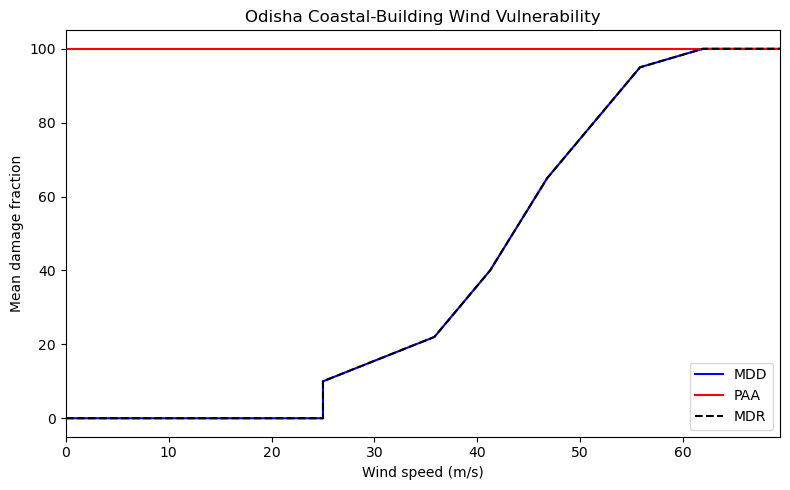

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

impf_odisha.plot(axis=ax)

ax.set_title("Odisha Coastal-Building Wind Vulnerability")
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Mean damage fraction")

plt.tight_layout()
plt.show()

The Odisha vulnerability function was digitized approximately from the published OSDMA-based coastal-building damage curve. The source provides the relationship graphically rather than as a numerical table; therefore, the digitized points should be regarded as approximate. Linear interpolation is used between published/digitized points, while damage below the first reported wind speed of 90 km/h is conservatively set to zero.

### Assigning functions to exposure

Each exposure point is tagged with the impact function it should use. This mapping is what
allows the same exposure set to be re-run under a different vulnerability assumption later in
the notebook without rebuilding anything.

In [10]:
exposure_baseline["impf_"] = 2
exposure_low["impf_"] = 2
exposure_high["impf_"] = 2

print(exposure_baseline["impf_"].value_counts())

impf_
2    525
Name: count, dtype: int64


In [11]:
impf_set_odisha = ImpactFuncSet()
impf_set_odisha.append(impf_odisha)

print(impf_set_odisha)

In [12]:
from climada.engine import ImpactCalc

In [13]:
from climada.entity import Exposures

In [14]:
exposure_baseline_climada = Exposures(exposure_baseline)
exposure_low_climada = Exposures(exposure_low)
exposure_high_climada = Exposures(exposure_high)

In [15]:
print(type(exposure_baseline_climada))
print(len(exposure_baseline_climada.gdf))

<class 'climada.entity.exposures.base.Exposures'>
525


In [16]:
print(exposure_baseline_climada.gdf["impf_"].value_counts())

impf_
2    525
Name: count, dtype: int64


## Baseline loss calculation

Combines hazard, exposure and vulnerability into an event-by-centroid loss matrix.

`save_mat=True` retains the full matrix rather than only aggregate totals, which is required
for the spatial attribution and Year Loss Table construction that follow.

In [17]:
impact_baseline = ImpactCalc(
    exposure_baseline_climada,
    impf_set_odisha,
    hazard
).impact(save_mat=True)

print("Impact calculation complete.")
print("Events:", len(impact_baseline.event_name))
print("Centroids:", len(impact_baseline.coord_exp))
print("AAL:", impact_baseline.aai_agg)

Impact calculation complete.
Events: 2754
Centroids: 525
AAL: 1532647372.2477934


In [18]:
print("AAL:", impact_baseline.aai_agg)
print("Total exposure:", exposure_baseline_climada.gdf["value"].sum())
print(
    "AAL as % exposure:",
    100 * impact_baseline.aai_agg /
    exposure_baseline_climada.gdf["value"].sum()
)

AAL: 1532647372.2477934
Total exposure: 144858095456.26517
AAL as % exposure: 1.0580336345168384


## Event-level loss attribution

Ranking events by total loss answers a question that intensity alone cannot: **which storms
actually drive the risk?**

The most intense storm in a catalogue is not necessarily the most damaging one. A moderate
storm tracking directly over concentrated exposure can produce greater loss than a severe storm
passing over a sparsely valued area. The correlation between peak wind and event loss is
computed later in the notebook to test this directly.

In [19]:
event_losses = np.asarray(impact_baseline.at_event)

print("Number of event losses:", len(event_losses))
print("Minimum event loss:", event_losses.min())
print("Maximum event loss:", event_losses.max())
print("Mean event loss:", event_losses.mean())
print("Non-zero event losses:", np.count_nonzero(event_losses))

Number of event losses: 2754
Minimum event loss: 0.0
Maximum event loss: 70965065738.02286
Mean event loss: 709558968.6332378
Non-zero event losses: 334


In [20]:
top_idx = np.argsort(event_losses)[-10:][::-1]

for i in top_idx:
    print(
        i,
        hazard.event_name[i],
        f"{event_losses[i]:,.2f}"
    )

1789 2019116N02090_gen4 70,965,065,738.02
1245 2013281N12098_gen21 59,322,069,940.71
1796 2019116N02090_gen11 54,857,408,945.26
1234 2013281N12098_gen10 50,795,812,229.43
1805 2019116N02090_gen20 50,587,956,311.09
1785 2019116N02090 46,906,613,859.28
1792 2019116N02090_gen7 45,135,875,171.71
1242 2013281N12098_gen18 44,468,396,223.20
1816 2019116N02090_gen31 40,651,833,069.82
1233 2013281N12098_gen9 37,951,996,979.89


In [21]:
worst = top_idx[0]

print("Event:", hazard.event_name[worst])
print("Total loss:", event_losses[worst])

print(
    "Maximum wind:",
    hazard.intensity[worst].max()
)

Event: 2019116N02090_gen4
Total loss: 70965065738.02286
Maximum wind: 68.17897474356577


## Spatial loss attribution

Decomposes average annual loss by grid cell, producing the accumulation view an underwriter
would ask for: *where is the risk concentrated?*

The check that follows - comparing summed spatial AAL against the aggregate figure confirms
that the decomposition is complete and that no loss has been lost or double-counted in the
process.

In [22]:
loss_matrix = impact_baseline.imp_mat.toarray()

print("Loss matrix shape:", loss_matrix.shape)

worst_losses = loss_matrix[worst]

top_cells = np.argsort(worst_losses)[-10:][::-1]

for j in top_cells:
    print(
        j,
        exposure_baseline_climada.gdf.geometry.iloc[j],
        f"Exposure: {exposure_baseline_climada.gdf.value.iloc[j]:,.0f}",
        f"Loss: {worst_losses[j]:,.0f}",
        f"Wind: {hazard.intensity[worst, j]:.2f} m/s"
    )

Loss matrix shape: (2754, 525)
340 POINT (85.75 20.25) Exposure: 20,685,660,874 Loss: 20,685,660,874 Wind: 62.10 m/s
366 POINT (86 20.5) Exposure: 10,481,361,708 Loss: 9,725,062,054 Wind: 55.17 m/s
365 POINT (85.75 20.5) Exposure: 7,990,105,670 Loss: 6,582,829,360 Wind: 52.04 m/s
341 POINT (86 20.25) Exposure: 6,429,632,199 Loss: 6,412,262,831 Wind: 61.61 m/s
290 POINT (85.75 19.75) Exposure: 4,643,005,007 Loss: 4,643,005,007 Wind: 66.97 m/s
236 POINT (84.75 19.25) Exposure: 9,145,423,934 Loss: 3,063,171,190 Wind: 39.29 m/s
367 POINT (86.25 20.5) Exposure: 1,958,725,867 Loss: 1,645,521,442 Wind: 52.53 m/s
392 POINT (86.25 20.75) Exposure: 2,891,525,086 Loss: 1,616,322,125 Wind: 44.78 m/s
315 POINT (85.75 20) Exposure: 1,198,124,994 Loss: 1,198,124,994 Wind: 66.27 m/s
416 POINT (86 21) Exposure: 3,698,608,198 Loss: 1,122,075,689 Wind: 38.34 m/s


In [23]:
aal_by_cell = np.sum(
    loss_matrix * hazard.frequency[:, None],
    axis=0
)

print("Number of cells:", len(aal_by_cell))
print("Total AAL:", aal_by_cell.sum())
print("Maximum cell AAL:", aal_by_cell.max())
print(
    "Difference from aggregate AAL:",
    aal_by_cell.sum() - impact_baseline.aai_agg
)

Number of cells: 525
Total AAL: 1532647372.2477934
Maximum cell AAL: 280164562.49464685
Difference from aggregate AAL: 0.0


In [24]:
centroids_odisha = gpd.read_file(
    output_dir / "odisha_exposure_grid.gpkg",
    layer="exposure_grid"
)

print("Centroids:", len(centroids_odisha))
print(centroids_odisha.head())

Centroids: 525
   value          geometry
0    0.0     POINT (82 17)
1    0.0  POINT (82.25 17)
2    0.0   POINT (82.5 17)
3    0.0  POINT (82.75 17)
4    0.0     POINT (83 17)


In [25]:
aal_map = centroids_odisha.copy()
aal_map["aal"] = aal_by_cell

print(
    aal_map.sort_values("aal", ascending=False)
    [["geometry", "aal"]]
    .head(10)
)

                geometry           aal
236  POINT (84.75 19.25)  2.801646e+08
340  POINT (85.75 20.25)  2.710523e+08
366      POINT (86 20.5)  1.160065e+08
290  POINT (85.75 19.75)  1.005063e+08
341     POINT (86 20.25)  9.528224e+07
365   POINT (85.75 20.5)  7.171405e+07
237     POINT (85 19.25)  4.427665e+07
261   POINT (84.75 19.5)  3.910028e+07
368    POINT (86.5 20.5)  3.066128e+07
470      POINT (87 21.5)  2.992497e+07


In [26]:
print(
    "Grid rows:", len(centroids_odisha),
    "| AAL values:", len(aal_by_cell)
)

Grid rows: 525 | AAL values: 525


In [27]:
print("Spatial AAL:", aal_by_cell.sum())
print("Aggregate AAL:", impact_baseline.aai_agg)
print(
    "Difference:",
    aal_by_cell.sum() - impact_baseline.aai_agg
)

Spatial AAL: 1532647372.2477934
Aggregate AAL: 1532647372.2477934
Difference: 0.0


## Return periods and exceedance probabilities

Converts the event loss distribution into the metrics used commercially: loss at specified
return periods, expressed as an exceedance probability curve.

Before interpreting these, it is worth establishing **how many catalogue events actually
support each estimate**. A return-period figure resting on a handful of events is a different
kind of number from one resting on hundreds, even though both are reported identically.

In [28]:
ep_methods = [
    x for x in dir(impact_baseline)
    if "freq" in x.lower()
    or "ep" in x.lower()
    or "year" in x.lower()
]

print(ep_methods)

['__repr__', 'calc_freq_curve', 'calc_impact_year_set', 'frequency', 'frequency_unit', 'impact_per_year']


In [29]:
print("Event frequency:", hazard.frequency[:10])
print("Unique frequencies:", np.unique(hazard.frequency))

Event frequency: [0.00078431 0.00078431 0.00078431 0.00078431 0.00078431 0.00078431
 0.00078431 0.00078431 0.00078431 0.00078431]
Unique frequencies: [0.00078431]


In [30]:
freq_curve = impact_baseline.calc_freq_curve()

print("Minimum return period:", freq_curve.return_per.min())
print("Maximum return period:", freq_curve.return_per.max())

Minimum return period: 0.4629629629629739
Maximum return period: 1275.0


In [31]:
print(
    "Maximum directly supported OEP return period:",
    1 / np.sum(hazard.frequency[event_losses > 0])
)

Maximum directly supported OEP return period: 3.8173652694610793


In [32]:
return_periods = np.array([10, 25, 50, 100, 200])

freq_curve = impact_baseline.calc_freq_curve(
    return_per=return_periods
)

for rp, loss in zip(
    freq_curve.return_per,
    freq_curve.impact
):
    print(f"1-in-{rp:.0f} year OEP loss: {loss:,.2f}")

1-in-10 year OEP loss: 2,659,744,904.25
1-in-25 year OEP loss: 11,914,811,210.63
1-in-50 year OEP loss: 21,604,253,164.13
1-in-100 year OEP loss: 35,374,454,854.55
1-in-200 year OEP loss: 46,177,486,164.40


In [33]:
for rp, threshold in zip(
    return_periods,
    freq_curve.impact
):
    n_events = np.sum(event_losses >= threshold)
    total_freq = np.sum(
        hazard.frequency[event_losses >= threshold]
    )

    print(
        f"1-in-{rp:.0f}: "
        f"{n_events} events | "
        f"exceedance frequency = {total_freq:.6f}/yr"
    )

1-in-10: 127 events | exceedance frequency = 0.099608/yr
1-in-25: 51 events | exceedance frequency = 0.040000/yr
1-in-50: 25 events | exceedance frequency = 0.019608/yr
1-in-100: 12 events | exceedance frequency = 0.009412/yr
1-in-200: 6 events | exceedance frequency = 0.004706/yr


## Extreme value analysis and why it was not used

Where the empirical tail is thinly supported, standard practice is to fit a parametric
distribution typically a Generalised Pareto Distribution (GPD) to exceedances above a
threshold and extrapolate.

That approach is tested here properly rather than assumed to work. Threshold selection is
assessed using mean residual life behaviour and parameter stability across candidate
thresholds.

**Outcome: the GPD fit was rejected.** The shape parameter drifted increasingly negative at
higher thresholds rather than stabilising, indicating no stable extreme-value regime. A
negative shape implies a bounded tail, which in this setting is consistent with a
*model-imposed* ceiling finite exposure, a saturating damage function, and a catalogue
derived from only 54 historical tracks rather than a genuine physical bound on cyclone loss.

Fitting the distribution regardless would have produced a smooth, authoritative-looking tail
unsupported by the data. Empirical estimates are retained instead, with their sampling
limitations stated explicitly.

In [34]:
# Inspect upper quantiles of non-zero event losses
positive_losses = event_losses[event_losses > 0]

for q in [0.90, 0.95, 0.975, 0.98, 0.99]:
    print(
        f"{q:.1%} quantile:",
        np.quantile(positive_losses, q)
    )

90.0% quantile: 16916254481.705868
95.0% quantile: 30688451924.593987
97.5% quantile: 39774386340.591835
98.0% quantile: 44695339065.689545
99.0% quantile: 50727219776.375435


In [35]:
# Candidate thresholds based on positive event losses
threshold_quantiles = np.arange(0.70, 0.96, 0.025)

thresholds = np.quantile(
    positive_losses,
    threshold_quantiles
)

mrl_values = []
n_exceedances = []

for u in thresholds:
    excess = positive_losses[positive_losses > u] - u

    mrl_values.append(excess.mean())
    n_exceedances.append(len(excess))

for q, u, mrl, n in zip(
    threshold_quantiles,
    thresholds,
    mrl_values,
    n_exceedances
):
    print(
        f"{q:.1%} | "
        f"threshold={u:,.0f} | "
        f"exceedances={n} | "
        f"mean excess={mrl:,.0f}"
    )

70.0% | threshold=4,559,177,956 | exceedances=100 | mean excess=12,735,250,933
72.5% | threshold=5,274,905,435 | exceedances=92 | mean excess=13,094,892,341
75.0% | threshold=6,545,219,982 | exceedances=84 | mean excess=13,027,696,317
77.5% | threshold=7,576,359,466 | exceedances=75 | mean excess=13,493,922,723
80.0% | threshold=9,073,336,344 | exceedances=67 | mean excess=13,512,676,782
82.5% | threshold=10,227,893,508 | exceedances=59 | mean excess=14,127,350,363
85.0% | threshold=11,915,207,895 | exceedances=50 | mean excess=14,846,109,376
87.5% | threshold=13,893,459,584 | exceedances=42 | mean excess=15,525,108,442
90.0% | threshold=16,916,254,482 | exceedances=34 | mean excess=15,877,217,176
92.5% | threshold=21,516,530,626 | exceedances=25 | mean excess=16,287,341,888
95.0% | threshold=30,688,451,925 | exceedances=17 | mean excess=12,756,838,419


In [36]:
import pandas as pd

In [37]:
from scipy.stats import genpareto

candidate_quantiles = np.arange(0.70, 0.951, 0.0125)

stability_results = []

for q in candidate_quantiles:
    u = np.quantile(positive_losses, q)
    excesses = positive_losses[positive_losses > u] - u

    if len(excesses) < 10:
        continue

    shape, loc, scale = genpareto.fit(
        excesses,
        floc=0
    )

    stability_results.append({
        "quantile": q,
        "threshold": u,
        "n": len(excesses),
        "shape": shape,
        "scale": scale
    })

stability_df = pd.DataFrame(stability_results)

print(stability_df.to_string(index=False))

 quantile    threshold   n     shape        scale
   0.7000 4.559178e+09 100  0.137453 1.103518e+10
   0.7125 5.009392e+09  96  0.136326 1.111404e+10
   0.7250 5.274905e+09  92  0.102060 1.178654e+10
   0.7375 5.604847e+09  88  0.073190 1.238887e+10
   0.7500 6.545220e+09  84  0.131051 1.137342e+10
   0.7625 7.169391e+09  80  0.142205 1.125530e+10
   0.7750 7.576359e+09  75  0.081288 1.241822e+10
   0.7875 8.242436e+09  71  0.080138 1.249958e+10
   0.8000 9.073336e+09  67  0.102859 1.216203e+10
   0.8125 9.371327e+09  63  0.019983 1.378282e+10
   0.8250 1.022789e+10  59  0.013062 1.394345e+10
   0.8375 1.090395e+10  55 -0.032675 1.492168e+10
   0.8500 1.191521e+10  50 -0.094004 1.627245e+10
   0.8625 1.248250e+10  46 -0.175142 1.835709e+10
   0.8750 1.389346e+10  42 -0.192624 1.862125e+10
   0.8875 1.491366e+10  38 -0.254762 2.032241e+10
   0.9000 1.691625e+10  34 -0.271242 2.033178e+10
   0.9125 1.805339e+10  30 -0.350319 2.275243e+10
   0.9250 2.151653e+10  25 -0.377123 2.248881e+10


In [38]:
n = len(event_losses)
mid = n // 2

loss_half_a = event_losses[:mid]
freq_half_a = hazard.frequency[:mid]

loss_half_b = event_losses[mid:]
freq_half_b = hazard.frequency[mid:]

def empirical_oep(losses, frequencies, return_period):
    idx = np.argsort(losses)[::-1]

    sorted_losses = losses[idx]
    sorted_freq = frequencies[idx]

    exceed_freq = np.cumsum(sorted_freq)

    target_freq = 1 / return_period

    # Return loss at the requested frequency
    return np.interp(
    target_freq,
    exceed_freq,
    sorted_losses
)

for name, losses, freqs in [
    ("Half A", loss_half_a, freq_half_a),
    ("Half B", loss_half_b, freq_half_b),
]:
    loss_100 = empirical_oep(losses, freqs, 100)

    print(
        f"{name} 1-in-100 OEP: "
        f"{loss_100:,.2f}"
    )

Half A 1-in-100 OEP: 16,003,754,544.21
Half B 1-in-100 OEP: 30,970,874,082.79


In [39]:
# Examine the empirical loss distribution around the 10- and 25-year levels

loss_10 = freq_curve.impact[0]
loss_25 = freq_curve.impact[1]

print("10-year threshold:", f"{loss_10:,.2f}")
print("25-year threshold:", f"{loss_25:,.2f}")

print("\nLargest losses around the 10–25 year region:")

sorted_losses = np.sort(event_losses[event_losses > 0])[::-1]

# Show the 60 largest non-zero event losses
for i, loss in enumerate(sorted_losses[:60], start=1):
    print(f"{i:3d}: {loss:,.2f}")

10-year threshold: 2,659,744,904.25
25-year threshold: 11,914,811,210.63

Largest losses around the 10–25 year region:
  1: 70,965,065,738.02
  2: 59,322,069,940.71
  3: 54,857,408,945.26
  4: 50,795,812,229.43
  5: 50,587,956,311.09
  6: 46,906,613,859.28
  7: 45,135,875,171.71
  8: 44,468,396,223.20
  9: 40,651,833,069.82
 10: 37,951,996,979.89
 11: 37,255,885,783.84
 12: 35,861,594,279.37
 13: 35,224,565,800.77
 14: 32,814,630,406.71
 15: 32,413,646,994.28
 16: 32,343,135,380.06
 17: 31,013,448,719.58
 18: 30,513,453,650.37
 19: 29,388,861,756.80
 20: 26,955,533,202.85
 21: 26,532,465,669.76
 22: 25,053,908,743.12
 23: 24,004,223,586.32
 24: 22,378,042,951.25
 25: 21,700,387,452.70
 26: 21,511,816,348.20
 27: 21,169,046,552.88
 28: 20,127,864,310.26
 29: 19,138,009,554.56
 30: 18,098,654,219.96
 31: 17,769,427,498.52
 32: 17,520,131,897.79
 33: 17,499,902,968.15
 34: 17,046,370,155.90
 35: 16,612,651,241.91
 36: 15,758,268,069.05
 37: 15,656,216,006.98
 38: 15,051,182,577.32
 39: 14

## Year Loss Table construction

Return-period losses so far are **occurrence**-based: they describe individual events. Annual
aggregate loss requires a different construction, because a single year may contain zero, one,
or several loss-producing events.

The catalogue cannot simply be grouped by year, because synthetic events carry annual
frequencies rather than calendar dates grouping perturbed variants of the same historical
storm into a single year would badly over-count.

Instead, annual losses are simulated directly:

1. Draw the number of loss-producing events in a year from a Poisson distribution with rate λ
2. Sample that many events, weighted by their individual frequencies, with replacement
3. Sum their losses to give the annual aggregate
4. Repeat over a large number of synthetic years

This yields an annual aggregate loss distribution, from which AEP and TVaR follow directly.

**Note on λ:** two distinct frequencies exist in this analysis. Total cyclone-event frequency
is ~2.16/year, but only ~0.262/year produce non-zero modelled loss. The Year Loss Table uses
the **loss-producing** rate, since zero-loss events do not contribute to annual aggregates.

In [40]:
impact_years = impact_baseline.calc_impact_year_set()

print(type(impact_years))
print(impact_years)
print("Number of years:", len(impact_years))

2026-09-05 04:00:51,844 - climada.engine.impact - WARNING - The use of Impact.calc_impact_year_set is deprecated.Use Impact.impact_per_year instead.
<class 'dict'>
{np.int64(2001): np.float64(0.0), np.int64(2002): np.float64(2029555125.621692), np.int64(2003): np.float64(0.0), np.int64(2004): np.float64(0.0), np.int64(2005): np.float64(0.0), np.int64(2006): np.float64(0.0), np.int64(2007): np.float64(11679761542.99112), np.int64(2008): np.float64(0.0), np.int64(2009): np.float64(0.0), np.int64(2010): np.float64(0.0), np.int64(2011): np.float64(0.0), np.int64(2012): np.float64(0.0), np.int64(2013): np.float64(596027686399.3282), np.int64(2014): np.float64(85211133760.17363), np.int64(2015): 0, np.int64(2016): np.float64(0.0), np.int64(2017): np.float64(0.0), np.int64(2018): np.float64(287019336064.31024), np.int64(2019): np.float64(877519918790.4443), np.int64(2020): np.float64(69698218506.76247), np.int64(2021): np.float64(15547823008.760633), np.int64(2022): np.float64(0.0), np.int64(

In [41]:
print(impact_baseline.frequency_unit)
print(impact_baseline.frequency[:5])

1/year
[0.00078431 0.00078431 0.00078431 0.00078431 0.00078431]


In [42]:
rng = np.random.default_rng(42)

n_years = 100_000

# Only events capable of producing loss
loss_event_mask = event_losses > 0

loss_values = event_losses[loss_event_mask]
loss_frequencies = hazard.frequency[loss_event_mask]

lambda_loss = loss_frequencies.sum()

# Probability of selecting each loss-producing event
event_prob = loss_frequencies / lambda_loss

print("Loss-producing events:", len(loss_values))
print("Annual loss-event rate:", lambda_loss)
print("Probability sum:", event_prob.sum())

Loss-producing events: 334
Annual loss-event rate: 0.2619607843137254
Probability sum: 1.0000000000000007


In [43]:
# Number of loss-producing events in each simulated year
n_events = rng.poisson(
    lambda_loss,
    size=n_years
)

annual_losses = np.zeros(n_years)
annual_max_losses = np.zeros(n_years)

for y, n in enumerate(n_events):

    if n > 0:

        selected = rng.choice(
            len(loss_values),
            size=n,
            replace=True,
            p=event_prob
        )

        selected_losses = loss_values[selected]

        # AEP quantity
        annual_losses[y] = selected_losses.sum()

        # OEP quantity
        annual_max_losses[y] = selected_losses.max()

In [44]:
print("Simulated years:", n_years)

print(
    "Zero-loss years:",
    np.mean(annual_losses == 0)
)

print(
    "Exactly-one-event years:",
    np.mean(n_events == 1)
)

print(
    "Two-or-more-event years:",
    np.mean(n_events >= 2)
)

print(
    "Mean annual loss:",
    annual_losses.mean()
)

print(
    "Original AAL:",
    impact_baseline.aai_agg
)

print(
    "Maximum annual aggregate loss:",
    annual_losses.max()
)

print(
    "Maximum single-event loss:",
    annual_max_losses.max()
)

Simulated years: 100000
Zero-loss years: 0.76946
Exactly-one-event years: 0.2014
Two-or-more-event years: 0.02914
Mean annual loss: 1516412615.1906126
Original AAL: 1532647372.2477934
Maximum annual aggregate loss: 92476882086.22342
Maximum single-event loss: 70965065738.02286


### OEP and AEP compared

Occurrence exceedance probability (largest single event in a year) and aggregate exceedance
probability (total annual loss) are reported side by side.

These are expected to lie close together in this analysis, and the reason is informative: with
a loss-producing event rate of ~0.26/year, the large majority of years contain at most one
loss event, so the annual total usually *is* the single largest event. The two metrics
diverge materially only in the far tail.

The distinction matters commercially: OEP drives per-occurrence reinsurance structures, AEP
drives aggregate covers.

In [45]:
return_periods = np.array([10, 25, 50, 100, 200])

def ylt_ep(losses, return_periods):
    """
    Empirical exceedance losses from a simulated
    annual loss table.
    """
    sorted_losses = np.sort(losses)[::-1]

    # Exceedance probability = 1 / return period
    probabilities = 1 / return_periods

    # Convert to descending empirical quantile position
    positions = probabilities * len(sorted_losses)

    return np.array([
        np.quantile(
            losses,
            1 - p,
            method="linear"
        )
        for p in probabilities
    ])

oep_ylt = ylt_ep(
    annual_max_losses,
    return_periods
)

aep_ylt = ylt_ep(
    annual_losses,
    return_periods
)

for rp, oep, aep in zip(
    return_periods,
    oep_ylt,
    aep_ylt
):
    print(
        f"1-in-{rp}: "
        f"OEP = ${oep:,.2f} | "
        f"AEP = ${aep:,.2f}"
    )

1-in-10: OEP = $2,469,212,743.37 | AEP = $2,477,421,862.84
1-in-25: OEP = $11,120,108,556.30 | AEP = $11,546,098,932.56
1-in-50: OEP = $21,169,046,552.88 | AEP = $21,700,387,452.70
1-in-100: OEP = $32,814,630,406.71 | AEP = $35,224,565,800.77
1-in-200: OEP = $45,135,875,171.71 | AEP = $45,135,875,171.71


In [46]:
aep_100 = aep_ylt[
    np.where(return_periods == 100)[0][0]
]

tvar_100 = annual_losses[
    annual_losses >= aep_100
].mean()

print("100-year AEP:", f"${aep_100:,.2f}")
print("100-year TVaR:", f"${tvar_100:,.2f}")
print(
    "Number of years above threshold:",
    np.sum(annual_losses >= aep_100)
)

100-year AEP: $35,224,565,800.77
100-year TVaR: $47,487,147,087.50
Number of years above threshold: 1034


In [47]:
for rp, oep, aep in zip(
    return_periods,
    oep_ylt,
    aep_ylt
):
    n_oep = np.sum(annual_max_losses >= oep)
    n_aep = np.sum(annual_losses >= aep)

    print(
        f"1-in-{rp}: "
        f"OEP exceedances={n_oep}, "
        f"AEP exceedances={n_aep}"
    )

1-in-10: OEP exceedances=10057, AEP exceedances=10000
1-in-25: OEP exceedances=4014, AEP exceedances=4000
1-in-50: OEP exceedances=2072, AEP exceedances=2014
1-in-100: OEP exceedances=1068, AEP exceedances=1034
1-in-200: OEP exceedances=508, AEP exceedances=538


## Sensitivity analysis

The single most important section of the notebook. A loss estimate is only as meaningful as
the assumptions it rests on, so each major assumption is varied in turn to establish which one
the answer actually depends on.

Four axes are tested:

| Axis | Variation |
|---|---|
| Vulnerability | Odisha-derived curve vs Emanuel (2011) US-calibrated |
| Exposure | ±30% scaling |
| Climate / hazard | +10% wind intensity |
| Catalogue size | Reduced stochastic event set |

The vulnerability comparison is run first, as a full re-computation of the loss chain under the
alternative damage function.

In [48]:
impf_emanuel = ImpfTropCyclone.from_emanuel_usa(
    impf_id=1
)

print(impf_emanuel)

In [49]:
impf_set_emanuel = ImpactFuncSet()
impf_set_emanuel.append(impf_emanuel)

print(impf_set_emanuel)

In [50]:
exposure_emanuel = Exposures(
    exposure_baseline.copy()
)

exposure_emanuel.gdf["impf_"] = 1

print(
    exposure_emanuel.gdf["impf_"].value_counts()
)

impf_
1    525
Name: count, dtype: int64


In [51]:
impact_emanuel = ImpactCalc(
    exposure_emanuel,
    impf_set_emanuel,
    hazard
).impact(
    save_mat=True
)

print("Emanuel impact calculation complete.")
print("AAL:", impact_emanuel.aai_agg)

Emanuel impact calculation complete.
AAL: 134278007.571949


In [52]:
# Emanuel event losses
emanuel_event_losses = impact_emanuel.at_event

print("Non-zero Emanuel events:",
      np.sum(emanuel_event_losses > 0))

print("Maximum Emanuel event loss:",
      emanuel_event_losses.max())

print("Mean event loss:",
      emanuel_event_losses.mean())

Non-zero Emanuel events: 334
Maximum Emanuel event loss: 15294608969.476038
Mean event loss: 62165744.24627269


In [53]:
# Build Emanuel loss-event catalogue
emanuel_mask = emanuel_event_losses > 0

emanuel_losses = emanuel_event_losses[emanuel_mask]
emanuel_freq = hazard.frequency[emanuel_mask]

lambda_emanuel = emanuel_freq.sum()

print("Emanuel loss events:", len(emanuel_losses))
print("Emanuel loss-event rate:", lambda_emanuel)

Emanuel loss events: 334
Emanuel loss-event rate: 0.2619607843137254


In [54]:
rng_emanuel = np.random.default_rng(42)

n_years = 100_000

n_events_emanuel = rng_emanuel.poisson(
    lambda_emanuel,
    size=n_years
)

emanuel_annual_losses = np.zeros(n_years)
emanuel_annual_max = np.zeros(n_years)

emanuel_prob = emanuel_freq / lambda_emanuel

for y, n in enumerate(n_events_emanuel):

    if n > 0:
        selected = rng_emanuel.choice(
            len(emanuel_losses),
            size=n,
            replace=True,
            p=emanuel_prob
        )

        selected_losses = emanuel_losses[selected]

        emanuel_annual_losses[y] = selected_losses.sum()
        emanuel_annual_max[y] = selected_losses.max()

print("Mean annual loss:",
      emanuel_annual_losses.mean())

print("Maximum annual aggregate:",
      emanuel_annual_losses.max())

print("Maximum single event:",
      emanuel_annual_max.max())

Mean annual loss: 132344195.49905668
Maximum annual aggregate: 16438936234.075863
Maximum single event: 15294608969.476038


### Reusable metric and Year Loss Table functions

Factored into functions so that each sensitivity case is evaluated by an identical procedure.
This matters for a comparison exercise: differences between cases should reflect the assumption
being varied, not incidental differences in how each case was processed.

In [55]:
def ylt_metrics(annual_losses, annual_max, return_periods):
    aep = np.array([
        np.quantile(
            annual_losses,
            1 - 1 / rp,
            method="linear"
        )
        for rp in return_periods
    ])

    oep = np.array([
        np.quantile(
            annual_max,
            1 - 1 / rp,
            method="linear"
        )
        for rp in return_periods
    ])

    tvar_100 = annual_losses[
        annual_losses >= aep[3]
    ].mean()

    return oep, aep, tvar_100


emanuel_oep, emanuel_aep, emanuel_tvar100 = ylt_metrics(
    emanuel_annual_losses,
    emanuel_annual_max,
    return_periods
)

for rp, oep, aep in zip(
    return_periods,
    emanuel_oep,
    emanuel_aep
):
    print(
        f"1-in-{rp}: "
        f"OEP = ${oep:,.2f} | "
        f"AEP = ${aep:,.2f}"
    )

print(
    "\n100-year TVaR:",
    f"${emanuel_tvar100:,.2f}"
)

1-in-10: OEP = $45,502,209.87 | AEP = $46,910,668.37
1-in-25: OEP = $786,700,526.98 | AEP = $800,066,017.04
1-in-50: OEP = $1,883,742,742.50 | AEP = $1,883,742,742.50
1-in-100: OEP = $3,296,667,657.60 | AEP = $3,371,980,405.00
1-in-200: OEP = $5,015,984,011.15 | AEP = $5,015,984,011.15

100-year TVaR: $6,441,467,149.79


In [56]:
from climada.entity import Exposures
from climada.engine import ImpactCalc

# --------------------------------------------------
# 1. Convert the low/high GeoDataFrames to CLIMADA
#    Exposures objects
# --------------------------------------------------

exposure_low_climada = Exposures(exposure_low.copy())
exposure_high_climada = Exposures(exposure_high.copy())

# --------------------------------------------------
# 2. Attach the Odisha vulnerability function
#    Your Odisha function has ID = 2
# --------------------------------------------------

exposure_low_climada.gdf["impf_"] = 2
exposure_high_climada.gdf["impf_"] = 2

# --------------------------------------------------
# 3. Run impact calculation
# --------------------------------------------------

impact_low = ImpactCalc(
    exposure_low_climada,
    impf_set_odisha,
    hazard
).impact(save_mat=True)

impact_high = ImpactCalc(
    exposure_high_climada,
    impf_set_odisha,
    hazard
).impact(save_mat=True)

In [57]:
print("LOW EXPOSURE")
print("Total exposure:", exposure_low_climada.gdf["value"].sum())
print("AAL:", impact_low.aai_agg)

print("\nBASELINE")
print("Total exposure:", exposure_baseline["value"].sum())
print("AAL:", impact_baseline.aai_agg)

print("\nHIGH EXPOSURE")
print("Total exposure:", exposure_high_climada.gdf["value"].sum())
print("AAL:", impact_high.aai_agg)

LOW EXPOSURE
Total exposure: 101400666819.38562
AAL: 1072853160.5734556

BASELINE
Total exposure: 144858095456.26517
AAL: 1532647372.2477934

HIGH EXPOSURE
Total exposure: 188315524093.1447
AAL: 1992441583.9221318


In [58]:
def build_ylt(event_losses, hazard_frequency, n_years=100_000, seed=42):

    rng = np.random.default_rng(seed)

    mask = event_losses > 0

    losses = event_losses[mask]
    frequencies = hazard_frequency[mask]

    lambda_loss = frequencies.sum()
    probabilities = frequencies / lambda_loss

    n_events = rng.poisson(
        lambda_loss,
        size=n_years
    )

    annual_losses = np.zeros(n_years)
    annual_max = np.zeros(n_years)

    for y, n in enumerate(n_events):

        if n > 0:
            selected = rng.choice(
                len(losses),
                size=n,
                replace=True,
                p=probabilities
            )

            selected_losses = losses[selected]

            annual_losses[y] = selected_losses.sum()
            annual_max[y] = selected_losses.max()

    return annual_losses, annual_max


# Build YLTs
low_annual, low_max = build_ylt(
    impact_low.at_event,
    hazard.frequency,
    seed=42
)

high_annual, high_max = build_ylt(
    impact_high.at_event,
    hazard.frequency,
    seed=42
)


# 100-year AEP
low_aep100 = np.quantile(
    low_annual, 0.99
)

high_aep100 = np.quantile(
    high_annual, 0.99
)

print("Exposure -30%")
print("AAL:", impact_low.aai_agg)
print("100-year AEP:", low_aep100)

print("\nExposure +30%")
print("AAL:", impact_high.aai_agg)
print("100-year AEP:", high_aep100)

Exposure -30%
AAL: 1072853160.5734556
100-year AEP: 24657196060.536198

Exposure +30%
AAL: 1992441583.9221318
100-year AEP: 45791935540.9958


In [59]:
print("BASELINE CHECK")
print("Events:", len(hazard.event_name))
print("Cells:", len(centroids_odisha))
print("AAL:", impact_baseline.aai_agg)
print("100-year AEP:", aep_ylt[3])
print("100-year OEP:", oep_ylt[3])
print("100-year TVaR:", tvar_100)

BASELINE CHECK
Events: 2754
Cells: 525
AAL: 1532647372.2477934
100-year AEP: 35224565800.76599
100-year OEP: 32814630406.71215
100-year TVaR: 47487147087.501465


### Catalogue size sensitivity

Tests how the results respond to the size of the stochastic event set. This addresses a
different question from the other sensitivity axes: not "is the input uncertain?" but "is the
catalogue large enough for the answer to be stable?"

In [60]:
def event_set_sensitivity(
    impact_obj,
    hazard_obj,
    fraction,
    seed=42,
    n_years=100_000
):
    rng = np.random.default_rng(seed)

    n_total = len(hazard_obj.event_name)
    n_select = int(round(n_total * fraction))

    # Random subset of events
    selected_idx = rng.choice(
        n_total,
        size=n_select,
        replace=False
    )

    losses_all = impact_obj.at_event[selected_idx]
    freq_all = hazard_obj.frequency[selected_idx]

    # Keep the original total annual frequency
    total_frequency = hazard_obj.frequency.sum()

    # Renormalise selected frequencies
    freq_subset = (
        freq_all / freq_all.sum()
    ) * total_frequency

    # Keep only loss-producing events
    mask = losses_all > 0

    losses = losses_all[mask]
    frequencies = freq_subset[mask]

    lambda_loss = frequencies.sum()

    probabilities = frequencies / lambda_loss

    # Simulate annual event counts
    n_events = rng.poisson(
        lambda_loss,
        size=n_years
    )

    annual_losses = np.zeros(n_years)
    annual_max = np.zeros(n_years)

    for y, n in enumerate(n_events):

        if n > 0:
            selected = rng.choice(
                len(losses),
                size=n,
                replace=True,
                p=probabilities
            )

            selected_losses = losses[selected]

            annual_losses[y] = selected_losses.sum()
            annual_max[y] = selected_losses.max()

    return {
        "n_events": n_select,
        "aal": annual_losses.mean(),
        "aep100": np.quantile(
            annual_losses,
            0.99
        ),
        "oep100": np.quantile(
            annual_max,
            0.99
        ),
        "max_event": losses.max(),
        "max_annual": annual_losses.max()
    }

In [61]:
results_event_size = []

for fraction in [0.50, 0.75, 1.00]:

    result = event_set_sensitivity(
        impact_baseline,
        hazard,
        fraction=fraction,
        seed=42,
        n_years=100_000
    )

    result["fraction"] = fraction

    results_event_size.append(result)

event_size_df = pd.DataFrame(
    results_event_size
)

print(event_size_df.to_string(index=False))

 n_events          aal       aep100       oep100    max_event   max_annual  fraction
     1377 1.771021e+09 4.446840e+10 4.446840e+10 7.096507e+10 1.061896e+11      0.50
     2066 1.549383e+09 3.522457e+10 3.522457e+10 5.932207e+10 1.037905e+11      0.75
     2754 1.529963e+09 3.522457e+10 3.522457e+10 7.096507e+10 9.749753e+10      1.00


## Historical loss back-test: Cyclone Fani

The hazard module validated Fani's *wind field* against observations. This step validates the
*modelled loss* against reported economic damage from the same event.

Agreement is not expected, and disagreement is not necessarily failure. The model is wind-only
and built on a proxy exposure base, while reported economic loss includes surge, flood, and
asset classes outside the model's scope. The value of the comparison lies in whether the
magnitude and direction of the difference are explicable.

In [62]:
# Find the original historical Fani event
event_names = np.atleast_1d(hazard.event_name)

fani_idx = np.where(
    event_names == "2019116N02090"
)[0]

print("Fani indices:", fani_idx)

for i in fani_idx:
    print(
        i,
        event_names[i],
        "Wind max:",
        hazard.intensity[i].max(),
        "Modelled loss:",
        impact_baseline.at_event[i]
    )

Fani indices: [1785]
1785 2019116N02090 Wind max: 68.04864448945104 Modelled loss: 46906613859.28382


For historical Cyclone Fani, the model estimates approximately $46.9 billion of wind-driven economic loss, compared with a reported Odisha loss estimate of $93.4 billion. The model therefore captures approximately 50% of reported losses. The gap is expected because the modeled framework represents wind damage to a LitPop proxy exposure using a wind-only vulnerability function, whereas reported economic losses encompass additional hazards and asset classes, including flooding, storm surge, infrastructure, agriculture and indirect economic impacts. The back-test therefore provides directional validation rather than calibration of the model to historical loss.

## Climate conditioning

An illustrative scenario in which cyclone wind intensity is scaled by +10%, with frequency,
exposure and vulnerability held constant.

This is deliberately a **sensitivity scenario rather than a climate projection**. It does not
represent a specific emissions pathway or time horizon; it isolates the question of how
responsive modelled loss is to hazard intensification, which is informative given the
non-linear shape of the damage function.

In [63]:
import copy
import numpy as np

hazard_climate = copy.deepcopy(hazard)

# Increase modeled wind intensity by 10%
hazard_climate.intensity = hazard_climate.intensity * 1.10

print("Baseline maximum intensity:",
      hazard.intensity.max())

print("Climate-scenario maximum intensity:",
      hazard_climate.intensity.max())

print("Frequency unchanged:",
      np.allclose(
          hazard_climate.frequency,
          hazard.frequency
      ))

Baseline maximum intensity: 69.70402139891429
Climate-scenario maximum intensity: 76.67442353880573
Frequency unchanged: True


In [64]:
impact_climate = ImpactCalc(
    exposure_baseline_climada,
    impf_set_odisha,
    hazard_climate
).impact(save_mat=True)

print("Climate-scenario AAL:",
      impact_climate.aai_agg)

print("Baseline AAL:",
      impact_baseline.aai_agg)

print(
    "AAL change (%):",
    100 * (
        impact_climate.aai_agg /
        impact_baseline.aai_agg - 1
    )
)

Climate-scenario AAL: 2149941504.927211
Baseline AAL: 1532647372.2477934
AAL change (%): 40.27633125903505


In [65]:
climate_annual, climate_max = build_ylt(
    impact_climate.at_event,
    hazard_climate.frequency,
    n_years=100_000,
    seed=42
)

climate_aep100 = np.quantile(
    climate_annual,
    0.99
)

climate_oep100 = np.quantile(
    climate_max,
    0.99
)

climate_tvar100 = climate_annual[
    climate_annual >= climate_aep100
].mean()

print("Climate scenario AAL:",
      climate_annual.mean())

print("Climate 100-year OEP:",
      climate_oep100)

print("Climate 100-year AEP:",
      climate_aep100)

print("Climate 100-year TVaR:",
      climate_tvar100)

Climate scenario AAL: 2138779179.7806277
Climate 100-year OEP: 48540934647.210205
Climate 100-year AEP: 49325256460.60431
Climate 100-year TVaR: 61128858892.36248


In [66]:
# ============================================================
# OCCURRENCE CAT XL YLT
# ============================================================

rng = np.random.default_rng(42)

n_years = 100_000

# Loss-producing event catalogue
mask = impact_baseline.at_event > 0

loss_values = impact_baseline.at_event[mask]
loss_frequencies = hazard.frequency[mask]

# Annual rate of loss-producing events
lambda_loss = loss_frequencies.sum()

# Event selection probabilities
event_prob = loss_frequencies / lambda_loss

# Number of events in each simulated year
n_events = rng.poisson(
    lambda_loss,
    size=n_years
)

# ------------------------------------------------------------
# Reinsurance tower
# ------------------------------------------------------------

layers = {
    "Layer 1": {"attachment": 12e9, "limit": 10e9},
    "Layer 2": {"attachment": 22e9, "limit": 15e9},
    "Layer 3": {"attachment": 37e9, "limit": 20e9},
}

# Annual recovery for each layer
annual_recoveries = {
    name: np.zeros(n_years)
    for name in layers
}

# Also retain annual aggregate and maximum event
annual_losses_xl = np.zeros(n_years)
annual_max_xl = np.zeros(n_years)

# ------------------------------------------------------------
# Simulate years
# ------------------------------------------------------------

for y, n in enumerate(n_events):

    if n == 0:
        continue

    selected = rng.choice(
        len(loss_values),
        size=n,
        replace=True,
        p=event_prob
    )

    event_losses_year = loss_values[selected]

    # Annual aggregate loss
    annual_losses_xl[y] = event_losses_year.sum()

    # Maximum individual event
    annual_max_xl[y] = event_losses_year.max()

    # Apply occurrence XL to EACH EVENT
    for name, layer in layers.items():

        attachment = layer["attachment"]
        limit = layer["limit"]

        recoveries = np.minimum(
            np.maximum(
                event_losses_year - attachment,
                0
            ),
            limit
        )

        # Sum individual event recoveries for the year
        annual_recoveries[name][y] = recoveries.sum()


# ------------------------------------------------------------
# Report layer statistics
# ------------------------------------------------------------

print("CAT XL OCCURRENCE LAYERS")
print("=" * 60)

for name, layer in layers.items():

    recovery = annual_recoveries[name]

    expected_loss = recovery.mean()

    attachment_probability = np.mean(
        annual_max_xl > layer["attachment"]
    )

    exhaustion_probability = np.mean(
        annual_max_xl >=
        layer["attachment"] + layer["limit"]
    )

    rate_on_line = expected_loss / layer["limit"]

    print(f"\n{name}")
    print(
        f"Structure: "
        f"${layer['limit']/1e9:.0f}B xs "
        f"${layer['attachment']/1e9:.0f}B"
    )

    print(
        f"Expected annual layer loss: "
        f"${expected_loss:,.2f}"
    )

    print(
        f"Rate on line: "
        f"{rate_on_line:.4%}"
    )

    print(
        f"Attachment probability: "
        f"{attachment_probability:.4%}"
    )

    print(
        f"Exhaustion probability: "
        f"{exhaustion_probability:.4%}"
    )

CAT XL OCCURRENCE LAYERS

Layer 1
Structure: $10B xs $12B
Expected annual layer loss: $265,051,613.86
Rate on line: 2.6505%
Attachment probability: 3.6890%
Exhaustion probability: 1.8480%

Layer 2
Structure: $15B xs $22B
Expected annual layer loss: $202,447,178.62
Rate on line: 1.3496%
Attachment probability: 1.8480%
Exhaustion probability: 0.8360%

Layer 3
Structure: $20B xs $37B
Expected annual layer loss: $85,596,261.09
Rate on line: 0.4280%
Attachment probability: 0.8360%
Exhaustion probability: 0.1570%


In [67]:
# ============================================================
# EMANUEL OCCURRENCE CAT XL SENSITIVITY
# ============================================================

rng = np.random.default_rng(42)

n_years = 100_000

# Emanuel loss-producing events
mask = emanuel_event_losses > 0

emanuel_losses = emanuel_event_losses[mask]
emanuel_frequencies = hazard.frequency[mask]

lambda_emanuel = emanuel_frequencies.sum()

emanuel_prob = (
    emanuel_frequencies / lambda_emanuel
)

n_events_emanuel = rng.poisson(
    lambda_emanuel,
    size=n_years
)

emanuel_annual_max = np.zeros(n_years)

emanuel_layer_recoveries = {
    name: np.zeros(n_years)
    for name in layers
}

# ------------------------------------------------------------
# Simulate
# ------------------------------------------------------------

for y, n in enumerate(n_events_emanuel):

    if n == 0:
        continue

    selected = rng.choice(
        len(emanuel_losses),
        size=n,
        replace=True,
        p=emanuel_prob
    )

    event_losses_year = emanuel_losses[selected]

    emanuel_annual_max[y] = event_losses_year.max()

    # Occurrence XL event by event
    for name, layer in layers.items():

        attachment = layer["attachment"]
        limit = layer["limit"]

        recoveries = np.minimum(
            np.maximum(
                event_losses_year - attachment,
                0
            ),
            limit
        )

        emanuel_layer_recoveries[name][y] = (
            recoveries.sum()
        )

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("EMANUEL CAT XL SENSITIVITY")
print("=" * 60)

for name, layer in layers.items():

    recovery = emanuel_layer_recoveries[name]

    expected_loss = recovery.mean()

    attachment_probability = np.mean(
        emanuel_annual_max > layer["attachment"]
    )

    exhaustion_probability = np.mean(
        emanuel_annual_max >=
        layer["attachment"] + layer["limit"]
    )

    rate_on_line = expected_loss / layer["limit"]

    print(f"\n{name}")

    print(
        f"Expected annual layer loss: "
        f"${expected_loss:,.2f}"
    )

    print(
        f"Rate on line: "
        f"{rate_on_line:.4%}"
    )

    print(
        f"Attachment probability: "
        f"{attachment_probability:.4%}"
    )

    print(
        f"Exhaustion probability: "
        f"{exhaustion_probability:.4%}"
    )

EMANUEL CAT XL SENSITIVITY

Layer 1
Expected annual layer loss: $2,800,417.62
Rate on line: 0.0280%
Attachment probability: 0.0850%
Exhaustion probability: 0.0000%

Layer 2
Expected annual layer loss: $0.00
Rate on line: 0.0000%
Attachment probability: 0.0000%
Exhaustion probability: 0.0000%

Layer 3
Expected annual layer loss: $0.00
Rate on line: 0.0000%
Attachment probability: 0.0000%
Exhaustion probability: 0.0000%


## Intensity versus loss

Tests the hypothesis raised earlier in the notebook: is event loss driven primarily by storm
intensity, or by the spatial relationship between track and exposure?

A weak-to-moderate correlation would indicate that where a storm goes matters as much as how
strong it is which has direct implications for accumulation management, since it means
portfolio concentration cannot be assessed on hazard severity alone.

In [68]:
# Top 10 events: loss vs maximum wind

event_names = np.atleast_1d(hazard.event_name)

top_idx = np.argsort(
    impact_baseline.at_event
)[::-1][:10]

for rank, i in enumerate(top_idx, 1):

    print(
        f"{rank:2d}. "
        f"{event_names[i]} | "
        f"Loss = ${impact_baseline.at_event[i]:,.0f} | "
        f"Max wind = {hazard.intensity[i].max():.2f} m/s"
    )

 1. 2019116N02090_gen4 | Loss = $70,965,065,738 | Max wind = 68.18 m/s
 2. 2013281N12098_gen21 | Loss = $59,322,069,941 | Max wind = 64.38 m/s
 3. 2019116N02090_gen11 | Loss = $54,857,408,945 | Max wind = 67.50 m/s
 4. 2013281N12098_gen10 | Loss = $50,795,812,229 | Max wind = 64.01 m/s
 5. 2019116N02090_gen20 | Loss = $50,587,956,311 | Max wind = 67.97 m/s
 6. 2019116N02090 | Loss = $46,906,613,859 | Max wind = 68.05 m/s
 7. 2019116N02090_gen7 | Loss = $45,135,875,172 | Max wind = 68.20 m/s
 8. 2013281N12098_gen18 | Loss = $44,468,396,223 | Max wind = 63.07 m/s
 9. 2019116N02090_gen31 | Loss = $40,651,833,070 | Max wind = 69.06 m/s
10. 2013281N12098_gen9 | Loss = $37,951,996,980 | Max wind = 64.03 m/s


In [69]:
# Correlation between maximum event wind and total event loss

losses = impact_baseline.at_event
max_winds = np.array([
    hazard.intensity[i].max()
    for i in range(len(event_names))
])

mask = losses > 0

corr = np.corrcoef(
    max_winds[mask],
    losses[mask]
)[0, 1]

print("Correlation: max wind vs event loss =", corr)

Correlation: max wind vs event loss = 0.4537062222167704


In [70]:
print(
    aal_map.nlargest(15, "aal")[["geometry", "aal"]].to_string()
)

                geometry           aal
236  POINT (84.75 19.25)  2.801646e+08
340  POINT (85.75 20.25)  2.710523e+08
366      POINT (86 20.5)  1.160065e+08
290  POINT (85.75 19.75)  1.005063e+08
341     POINT (86 20.25)  9.528224e+07
365   POINT (85.75 20.5)  7.171405e+07
237     POINT (85 19.25)  4.427665e+07
261   POINT (84.75 19.5)  3.910028e+07
368    POINT (86.5 20.5)  3.066128e+07
470      POINT (87 21.5)  2.992497e+07
262      POINT (85 19.5)  2.563881e+07
343   POINT (86.5 20.25)  2.136290e+07
392  POINT (86.25 20.75)  2.115019e+07
344  POINT (86.75 20.25)  2.067072e+07
315     POINT (85.75 20)  2.043654e+07


## Results and figures

Generates the figures used in the project README and risk brief: the sensitivity ranking,
vulnerability function comparison, exceedance curves, spatial AAL, and the reinsurance layer
pricing comparison.

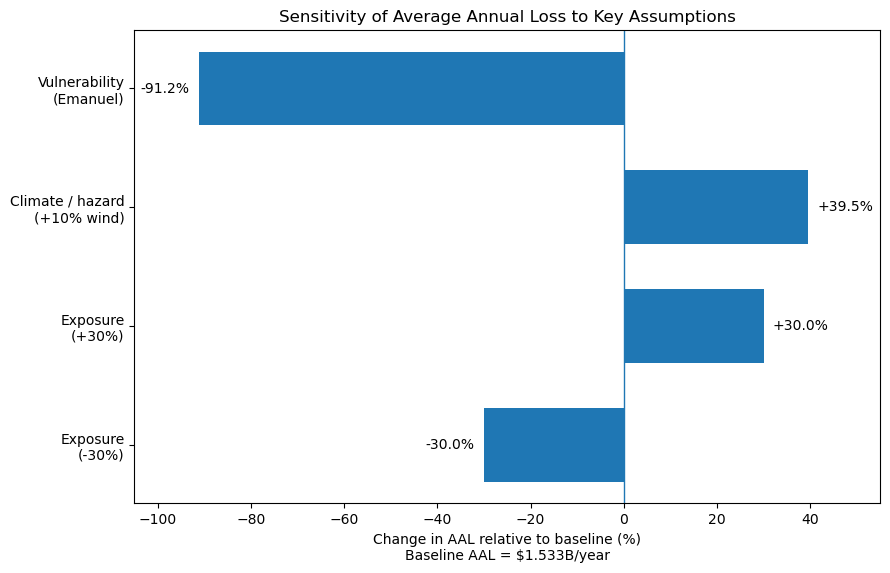

In [71]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Final AAL results
baseline_aal = 1.5326473722477934e9

sensitivity_aal = {
    "Vulnerability\n(Emanuel)": 134278007.571949,
    "Exposure\n(-30%)": 1072853160.5734556,
    "Exposure\n(+30%)": 1992441583.9221318,
    "Climate / hazard\n(+10% wind)": climate_annual.mean(),
}

labels = list(sensitivity_aal.keys())
values = np.array(list(sensitivity_aal.values()))

# Percentage change relative to baseline
pct_change = (values / baseline_aal - 1) * 100

# Sort by magnitude of effect
order = np.argsort(np.abs(pct_change))[::-1]

labels = [labels[i] for i in order]
pct_change = pct_change[order]

# -----------------------------
# Plot
# -----------------------------

fig, ax = plt.subplots(figsize=(9, 5.8))

y = np.arange(len(labels))

ax.barh(y, pct_change, height=0.62)
ax.axvline(0, linewidth=1)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Change in AAL relative to baseline (%)")
ax.set_title("Sensitivity of Average Annual Loss to Key Assumptions")

ax.invert_yaxis()

# Fixed limits leave room for annotations
ax.set_xlim(-105, 55)

# Percentage labels
for yi, change in zip(y, pct_change):

    if change < 0:
        ax.text(
            change - 2,
            yi,
            f"{change:+.1f}%",
            va="center",
            ha="right"
        )
    else:
        ax.text(
            change + 2,
            yi,
            f"{change:+.1f}%",
            va="center",
            ha="left"
        )

# Baseline note
ax.text(
    0.5,
    -0.12,
    "Baseline AAL = $1.533B/year",
    transform=ax.transAxes,
    ha="center"
)

plt.tight_layout()

# Save
figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_dir / "sensitivity_tornado.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

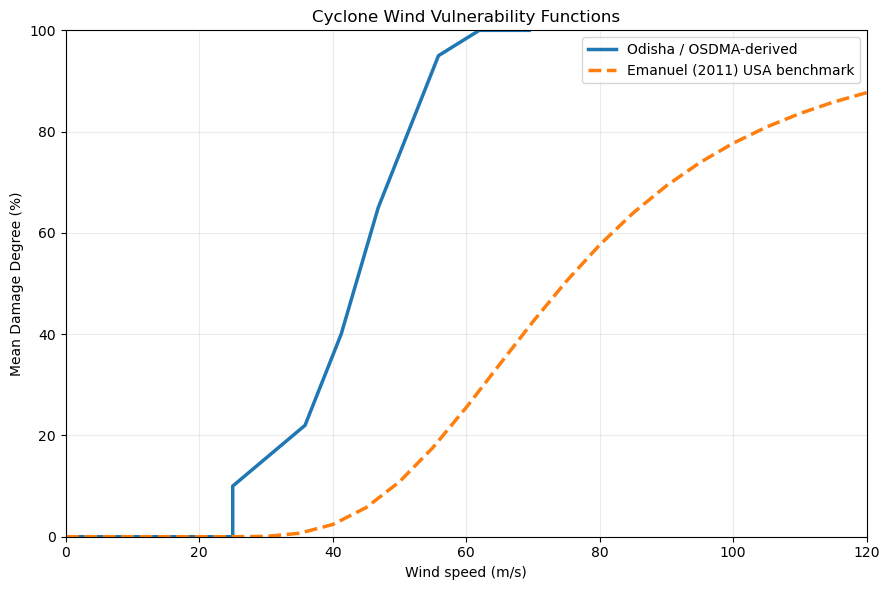

In [72]:
import os
import numpy as np
import matplotlib.pyplot as plt

figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 6))

# Odisha / OSDMA vulnerability curve
ax.plot(
    impf_odisha.intensity,
    impf_odisha.mdd * 100,
    linewidth=2.5,
    label="Odisha / OSDMA-derived"
)

# Emanuel benchmark
ax.plot(
    impf_emanuel.intensity,
    impf_emanuel.mdd * 100,
    linewidth=2.5,
    linestyle="--",
    label="Emanuel (2011) USA benchmark"
)

ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Mean Damage Degree (%)")
ax.set_title("Cyclone Wind Vulnerability Functions")

ax.set_xlim(
    0,
    max(
        np.max(impf_odisha.intensity),
        np.max(impf_emanuel.intensity)
    )
)

ax.set_ylim(0, 100)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    figures_dir / "vulnerability_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
baseline_annual, baseline_max = build_ylt(
    impact_baseline.at_event,
    hazard.frequency,
    n_years=100_000,
    seed=42
)

print("Baseline YLT built")
print("AAL:", baseline_annual.mean())
print("Maximum annual loss:", baseline_annual.max())
print("Maximum single-event loss:", baseline_max.max())

Baseline YLT built
AAL: 1516412615.1906126
Maximum annual loss: 92476882086.22342
Maximum single-event loss: 70965065738.02286


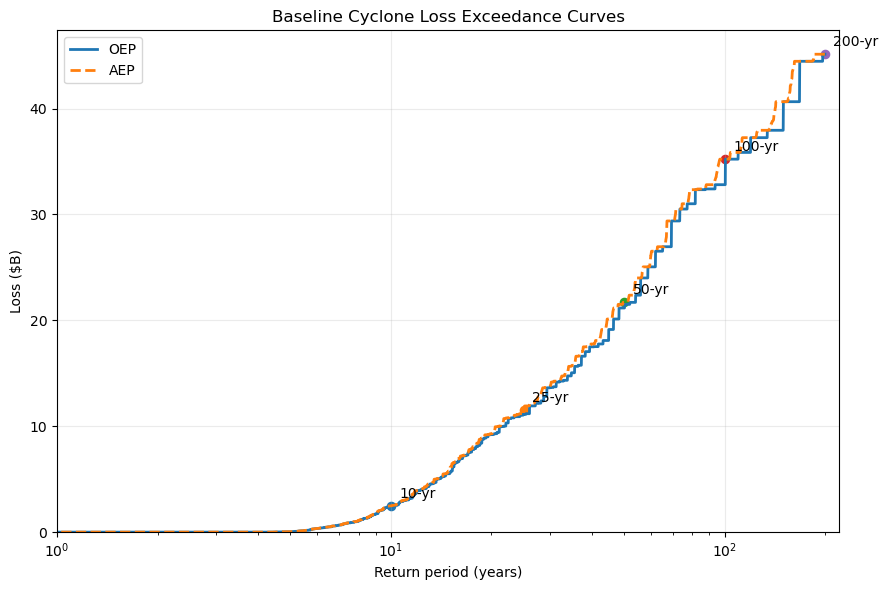

In [74]:
import os
import numpy as np
import matplotlib.pyplot as plt

figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------
# Sort YLT losses from largest to smallest
# -------------------------------------------------------

n_years = len(baseline_annual)

ranks = np.arange(1, n_years + 1)

aep_sorted = np.sort(baseline_annual)[::-1]
oep_sorted = np.sort(baseline_max)[::-1]

return_period = (n_years + 1) / ranks

# Only show the range used in the analysis
plot_mask = return_period <= 200

rp = return_period[plot_mask]
aep = aep_sorted[plot_mask] / 1e9
oep = oep_sorted[plot_mask] / 1e9

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    rp,
    oep,
    linewidth=2,
    label="OEP"
)

ax.plot(
    rp,
    aep,
    linewidth=2,
    linestyle="--",
    label="AEP"
)

# -------------------------------------------------------
# Mark key return periods
# -------------------------------------------------------

key_rps = [10, 25, 50, 100, 200]

for rp_target in key_rps:

    idx = np.argmin(np.abs(rp - rp_target))

    ax.scatter(
        rp[idx],
        aep[idx],
        s=35
    )

    ax.annotate(
        f"{rp_target}-yr",
        (rp[idx], aep[idx]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10
    )

# -------------------------------------------------------
# Formatting
# -------------------------------------------------------

ax.set_xscale("log")

ax.set_xlabel("Return period (years)")
ax.set_ylabel("Loss ($B)")

ax.set_title(
    "Baseline Cyclone Loss Exceedance Curves"
)

ax.set_xlim(1, 220)
ax.set_ylim(bottom=0)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    figures_dir / "oep_aep_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

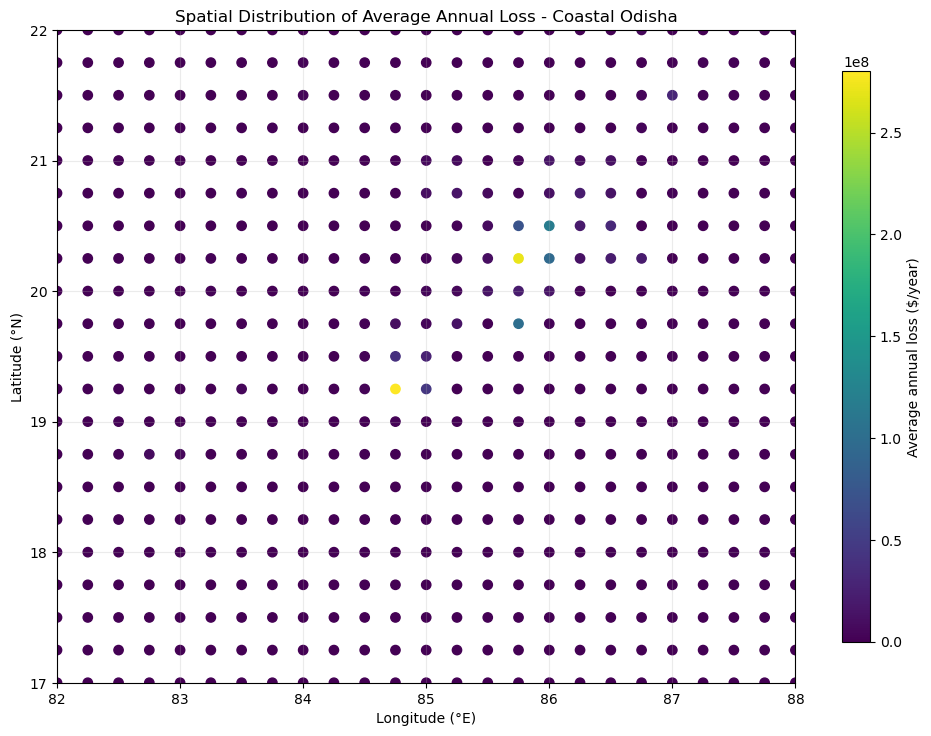

In [75]:
import os
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Spatial Average Annual Loss
aal_map.plot(
    ax=ax,
    column="aal",
    cmap="viridis",
    markersize=45,
    legend=True,
    legend_kwds={
        "label": "Average annual loss ($/year)",
        "shrink": 0.75
    }
)

ax.set_xlim(82, 88)
ax.set_ylim(17, 22)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Spatial Distribution of Average Annual Loss - Coastal Odisha")

ax.grid(alpha=0.25)

plt.tight_layout()

figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_dir / "aal_spatial_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Reinsurance structure and pricing

The final step, translating a modelled loss distribution into an indicative price.

A CAT XL tower is defined with attachment anchored near the 1-in-25 empirical OEP, so the
cedant retains losses expected roughly once a generation and transfers severity above that
point. The cover is treated as **occurrence**-based, so each event is tested against the
attachment independently.

For each layer, the recovery is:

```
recovery = min(max(loss - attachment, 0), limit)
```

Reported per layer: expected loss to layer, technical rate on line (expected loss ÷ limit),
and attachment probability.

Crucially, layer pricing is also computed under the alternative vulnerability function. This
carries the project's central uncertainty finding all the way through to the commercial
output showing not merely that vulnerability assumptions move the loss estimate, but that
they move the *price*.

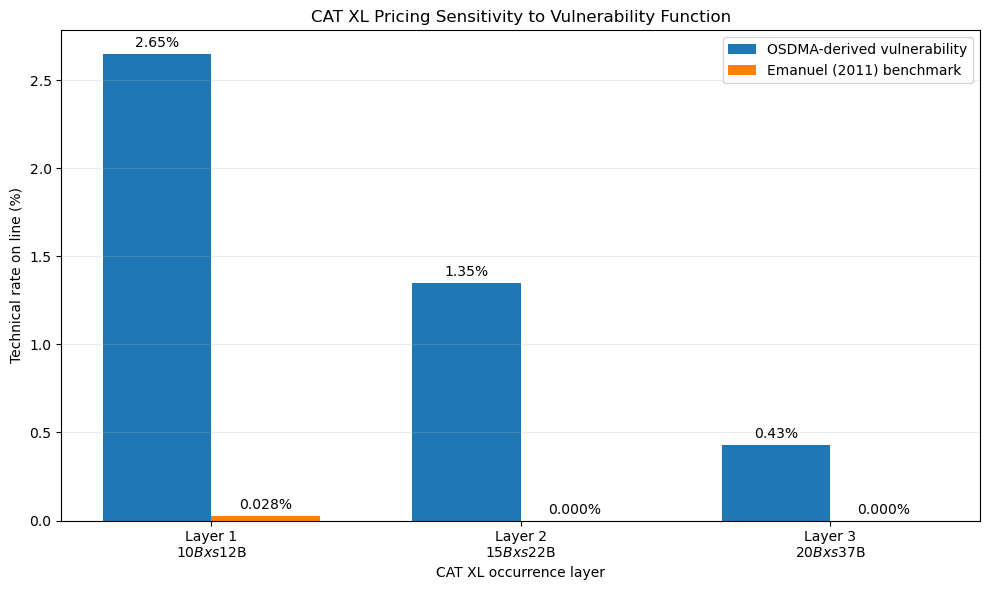

In [76]:
import os
import numpy as np
import matplotlib.pyplot as plt

figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------
# Reinsurance layer results
# -------------------------------------------------------

layer_names = [
    "Layer 1\n$10B xs $12B",
    "Layer 2\n$15B xs $22B",
    "Layer 3\n$20B xs $37B"
]

baseline_rol = np.array([
    0.026505,
    0.013496,
    0.004280
])

emanuel_rol = np.array([
    0.000280,
    0.000000,
    0.000000
])

x = np.arange(len(layer_names))
width = 0.35

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    baseline_rol * 100,
    width,
    label="OSDMA-derived vulnerability"
)

ax.bar(
    x + width / 2,
    emanuel_rol * 100,
    width,
    label="Emanuel (2011) benchmark"
)

# Labels
for i, value in enumerate(baseline_rol * 100):
    ax.annotate(
        f"{value:.2f}%",
        (i - width / 2, value),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center"
    )

for i, value in enumerate(emanuel_rol * 100):
    label = f"{value:.3f}%"
    
    ax.annotate(
        label,
        (i + width / 2, value),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center"
    )

ax.set_xticks(x)
ax.set_xticklabels(layer_names)

ax.set_ylabel("Technical rate on line (%)")
ax.set_xlabel("CAT XL occurrence layer")

ax.set_title(
    "CAT XL Pricing Sensitivity to Vulnerability Function"
)

ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    figures_dir / "cat_xl_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

## Impact stage conclusion

### Headline results

| Metric | Value |
|---|---|
| Total modelled exposure | $144.86B |
| Average Annual Loss | $1.533B/yr (1.06% of exposure) |
| 100-year OEP | $32.81B |
| 100-year AEP | $35.22B |
| 100-year TVaR | $47.49B |
| CAT XL Layer 1 ($10B xs $12B) | 2.65% technical rate on line |

### Principal finding

**Vulnerability specification dominates the uncertainty budget.** The Odisha-derived damage
function produces an AAL approximately **11.4× higher** than the Emanuel (2011) US-calibrated
benchmark under identical hazard and exposure. This exceeds the effect of a +10% wind
intensification (~40% AAL increase) and of ±30% exposure variation (approximately
proportional), and it propagates directly into reinsurance layer pricing.

The practical implication: for this domain, **regional vulnerability calibration would improve
the reliability of loss and pricing estimates more than further refinement of the hazard
model.**

### Secondary findings

- Loss is **highly spatially concentrated** - the five highest-AAL cells account for ~56% of
  total modelled AAL
- Peak wind correlates only moderately with event loss (**r = 0.454**), indicating that track
  position relative to concentrated exposure matters alongside storm severity
- OEP and AEP lie close together across most of the curve, a consequence of the low
  loss-producing event rate (~0.26/year)

### Limitations

- **Wind peril only.** Storm surge and rainfall flooding are excluded, despite being material
  loss drivers on this coastline. This is the largest scope limitation and likely explains a
  substantial part of the Fani back-test gap ($46.91B modelled vs $93.36B reported).
- **Economic, not insured, loss.** No policy terms, deductibles or limits are represented.
- **Vulnerability applied unstratified.** The source curve distinguishes construction types,
  but no spatial building-type inventory was available, so a single blended curve was used.
- **Tail estimates are sampling-limited** beyond 1-in-50 years: the 1-in-100 rests on ~12
  catalogue events and the 1-in-200 on ~6.
- **Catalogue ceiling.** Maximum modelled loss is bounded by construction, not by physics.